# 08 - Narrative Evaluation
Member 3 (Explainability & Narrative Engineer)
---

## Step 1 - Setup

In [2]:
import os, sys, json, re
from pathlib import Path

sys.path.insert(0, os.path.abspath('../src'))
import config as C

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['savefig.dpi'] = 200

NARR_DIR   = C.RESULTS_DIR / 'narratives'
PLOTS_DIR  = C.FIGURES_DIR / 'narrative_evaluation'
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

CLASS_COLORS = {'Healthy': '#2E7D32', 'At-Risk': '#F9A825', 'Distressed': '#C62828'}

print('Narratives folder:', NARR_DIR)
print('Plots folder:     ', PLOTS_DIR)

Narratives folder: D:\Collage\SEM 2\Deep Learning  Generative AI\Group Project\h9dlga-financial-health\project\results\narratives
Plots folder:      D:\Collage\SEM 2\Deep Learning  Generative AI\Group Project\h9dlga-financial-health\project\results\figures\narrative_evaluation


## Step 2 - Load Narratives

In [3]:
jsonl_path = NARR_DIR / 'narratives.jsonl'
if not jsonl_path.exists():
    raise FileNotFoundError(f'{jsonl_path} not found. Run notebook 07 first.')

records = [json.loads(l) for l in open(jsonl_path)]
df = pd.DataFrame(records)

print(f'Loaded {len(df)} narratives.')
print(f'Errors: {df.error.notna().sum()}')
print(f'Missing narratives: {df.narrative.isna().sum()}')
print()
print('Composition:')
print(df.groupby(["predicted_label", "correct"]).size().unstack(fill_value=0))

Loaded 100 narratives.
Errors: 0
Missing narratives: 0

Composition:
correct          False  True 
predicted_label              
At-Risk             11     25
Distressed           7     25
Healthy              7     25


## Step 3 - Metric 1: Feature Faithfulness

In [4]:
def variants(feature_name: str) -> list[str]:
    """Return the plausible surface forms of a feature name."""
    fn = str(feature_name).strip()
    spaced = fn.replace('_', ' ')
    hyphen = fn.replace('_', '-')
    # dedupe while preserving order
    seen, out = set(), []
    for v in (fn, spaced, hyphen):
        low = v.lower()
        if low not in seen:
            out.append(v); seen.add(low)
    return out

def feature_mentioned(narrative: str, feature_name: str) -> bool:
    if not isinstance(narrative, str) or not isinstance(feature_name, str):
        return False
    text = narrative.lower()
    return any(v.lower() in text for v in variants(feature_name))

df['top1_mentioned'] = df.apply(lambda r: feature_mentioned(r.narrative, r.top1_feature), axis=1)
df['top2_mentioned'] = df.apply(lambda r: feature_mentioned(r.narrative, r.top2_feature), axis=1)
df['top3_mentioned'] = df.apply(lambda r: feature_mentioned(r.narrative, r.top3_feature), axis=1)

df['n_mentioned'] = (
    df.top1_mentioned.astype(int) + df.top2_mentioned.astype(int) + df.top3_mentioned.astype(int)
)
df['all_three_mentioned'] = df.n_mentioned == 3

print(f'Narratives mentioning all 3 top features:   {df.all_three_mentioned.mean()*100:5.1f}%  '
      f'({df.all_three_mentioned.sum()}/{len(df)})')
print(f'Narratives mentioning top-1 feature:        {df.top1_mentioned.mean()*100:5.1f}%')
print(f'Narratives mentioning top-2 feature:        {df.top2_mentioned.mean()*100:5.1f}%')
print(f'Narratives mentioning top-3 feature:        {df.top3_mentioned.mean()*100:5.1f}%')
print(f'Mean number of top features mentioned:      {df.n_mentioned.mean():.2f} / 3')

Narratives mentioning all 3 top features:    98.0%  (98/100)
Narratives mentioning top-1 feature:        100.0%
Narratives mentioning top-2 feature:        100.0%
Narratives mentioning top-3 feature:         98.0%
Mean number of top features mentioned:      2.98 / 3


In [5]:
## Step 4 - Metric 2: Numeric Fidelity
NUM_RE = re.compile(r'-?\d+\.?\d*')

def extract_numbers(text: str) -> set[float]:
    if not isinstance(text, str):
        return set()
    out = set()
    for match in NUM_RE.findall(text):
        try:
            out.add(float(match))
        except ValueError:
            continue
    return out

def is_supported(number: float, allowed: set[float], tol=0.05) -> bool:
    """Return True if number is within tolerance of any allowed value, or is a percentage form of one."""
    for a in allowed:
        if abs(number - a) < tol:
            return True
        # 0.03 <-> 3
        if abs(number * 100 - a * 100) < 5 and abs(number) <= 1:
            return True
        if abs(a * 100 - number) < 5 and abs(a) <= 1:
            return True
    return False

def numeric_fidelity(prompt: str, narrative: str):
    prompt_nums    = extract_numbers(prompt)
    narrative_nums = extract_numbers(narrative)
    if not narrative_nums:
        return {'n_numbers_in_narrative': 0, 'n_hallucinated': 0, 'hallucination_rate': 0.0,
                'hallucinated_numbers': []}
    hallucinated = [n for n in narrative_nums if not is_supported(n, prompt_nums)]
    return {
        'n_numbers_in_narrative': len(narrative_nums),
        'n_hallucinated':         len(hallucinated),
        'hallucination_rate':     len(hallucinated) / len(narrative_nums),
        'hallucinated_numbers':   sorted(hallucinated),
    }

fid = df.apply(lambda r: pd.Series(numeric_fidelity(r.prompt, r.narrative)), axis=1)
df = pd.concat([df, fid], axis=1)

print(f'Mean numbers per narrative:            {df.n_numbers_in_narrative.mean():.1f}')
print(f'Mean hallucinated numbers per row:     {df.n_hallucinated.mean():.2f}')
print(f'Overall hallucination rate:            {df.hallucination_rate.mean()*100:.2f}%')
print(f'Rows with zero hallucinated numbers:   {(df.n_hallucinated == 0).mean()*100:.1f}%')

Mean numbers per narrative:            6.0
Mean hallucinated numbers per row:     0.00
Overall hallucination rate:            0.00%
Rows with zero hallucinated numbers:   100.0%


## Step 5 - Metric 3: Length Compliance

In [6]:
df['word_count'] = df.narrative.fillna('').apply(lambda s: len(s.split()))
df['length_ok']  = df.word_count.between(120, 180)

print(f'Word count summary:')
print(df.word_count.describe().round(1))
print()
print(f'% within target range (120-180 words):  {df.length_ok.mean()*100:.1f}%')

Word count summary:
count    100.0
mean     151.1
std       13.8
min      110.0
25%      141.0
50%      150.0
75%      160.0
max      200.0
Name: word_count, dtype: float64

% within target range (120-180 words):  97.0%


## Step 6 - Metric Breakdown by Predicted Class

In [7]:
by_class = df.groupby('predicted_label').agg(
    n=('narrative', 'size'),
    all_three_pct=('all_three_mentioned', lambda s: round(s.mean() * 100, 1)),
    mean_mentions=('n_mentioned', lambda s: round(s.mean(), 2)),
    hallucination_rate=('hallucination_rate', lambda s: round(s.mean() * 100, 2)),
    length_ok_pct=('length_ok', lambda s: round(s.mean() * 100, 1)),
    mean_word_count=('word_count', lambda s: round(s.mean(), 1)),
)

print('Per-class metrics:')
by_class

Per-class metrics:


,n,all_three_pct,mean_mentions,hallucination_rate,length_ok_pct,mean_word_count
predicted_label,,,,,,
At-Risk,36,100.0,3.00,0.0,97.2,154.1
Distressed,32,100.0,3.00,0.0,93.8,151.4
Healthy,32,93.8,2.94,0.0,100.0,147.4


In [8]:
# Same breakdown, correct vs incorrect predictions - does narrative quality drop when the model is wrong?
by_correct = df.groupby('correct').agg(
    n=('narrative', 'size'),
    all_three_pct=('all_three_mentioned', lambda s: round(s.mean() * 100, 1)),
    hallucination_rate=('hallucination_rate', lambda s: round(s.mean() * 100, 2)),
    mean_word_count=('word_count', lambda s: round(s.mean(), 1)),
)
print('Correct vs incorrect predictions:')
by_correct

Correct vs incorrect predictions:


,n,all_three_pct,hallucination_rate,mean_word_count
correct,,,,
False,25,100.0,0.0,151.6
True,75,97.3,0.0,150.9


## Step 7 - Visualisations for the Paper

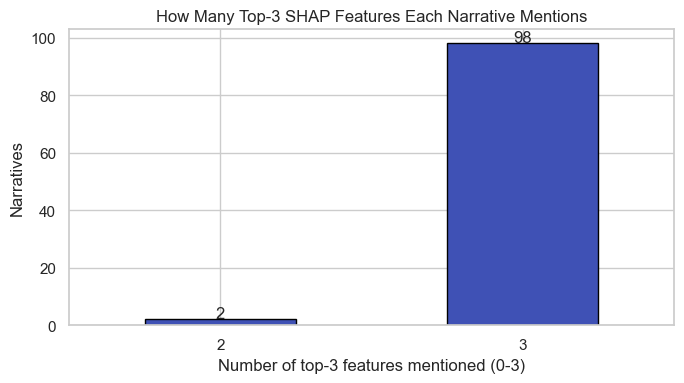

In [9]:
# Plot 1 - Faithfulness distribution
fig, ax = plt.subplots(figsize=(7, 4))
counts = df.n_mentioned.value_counts().sort_index()
counts.plot(kind='bar', ax=ax, color='#3F51B5', edgecolor='black')
for i, v in enumerate(counts):
    ax.text(i, v + 0.5, str(v), ha='center')
ax.set_title('How Many Top-3 SHAP Features Each Narrative Mentions')
ax.set_xlabel('Number of top-3 features mentioned (0-3)')
ax.set_ylabel('Narratives')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(PLOTS_DIR / '01_feature_faithfulness.png', bbox_inches='tight')
plt.show()

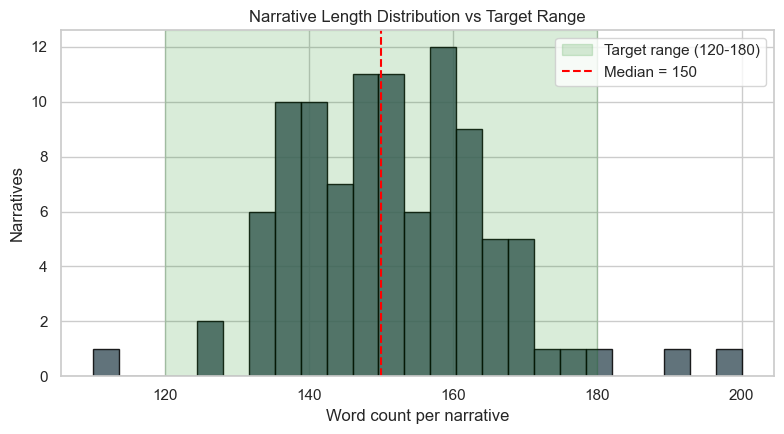

In [10]:
# Plot 2 - Word-count histogram with target band
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(df.word_count, bins=25, color='#455A64', edgecolor='black', alpha=0.85)
ax.axvspan(120, 180, alpha=0.15, color='green', label='Target range (120-180)')
ax.axvline(df.word_count.median(), color='red', linestyle='--', label=f'Median = {df.word_count.median():.0f}')
ax.set_xlabel('Word count per narrative')
ax.set_ylabel('Narratives')
ax.set_title('Narrative Length Distribution vs Target Range')
ax.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / '02_length_distribution.png', bbox_inches='tight')
plt.show()

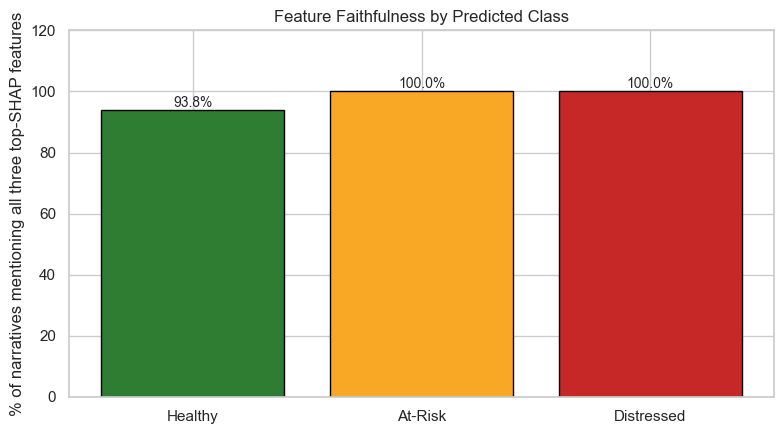

In [11]:
# Plot 3 - Per-class faithfulness comparison
fig, ax = plt.subplots(figsize=(8, 4.5))
classes = ['Healthy', 'At-Risk', 'Distressed']
vals = [by_class.loc[c, 'all_three_pct'] if c in by_class.index else 0 for c in classes]
colors = [CLASS_COLORS[c] for c in classes]
bars = ax.bar(classes, vals, color=colors, edgecolor='black')
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{v:.1f}%',
            ha='center', fontsize=10)
ax.set_ylim(0, max(vals) * 1.15 + 5)
ax.set_ylabel('% of narratives mentioning all three top-SHAP features')
ax.set_title('Feature Faithfulness by Predicted Class')
plt.tight_layout()
plt.savefig(PLOTS_DIR / '03_faithfulness_by_class.png', bbox_inches='tight')
plt.show()

## Step 8 - Save Per-Row Scores

In [12]:
score_cols = ['company_id', 'year', 'true_label', 'predicted_label', 'correct',
              'top1_feature', 'top1_mentioned',
              'top2_feature', 'top2_mentioned',
              'top3_feature', 'top3_mentioned',
              'n_mentioned', 'all_three_mentioned',
              'word_count', 'length_ok',
              'n_numbers_in_narrative', 'n_hallucinated', 'hallucination_rate']

scores = df[score_cols].copy()
score_path = NARR_DIR / 'faithfulness_scores.csv'
scores.to_csv(score_path, index=False)
print(f'Saved: {score_path}')

summary = {
    'n_narratives':               int(len(df)),
    'feature_faithfulness_pct':   round(float(df.all_three_mentioned.mean() * 100), 2),
    'mean_top_features_mentioned': round(float(df.n_mentioned.mean()), 3),
    'hallucination_rate_pct':     round(float(df.hallucination_rate.mean() * 100), 2),
    'zero_hallucinations_pct':    round(float((df.n_hallucinated == 0).mean() * 100), 2),
    'mean_word_count':            round(float(df.word_count.mean()), 1),
    'length_compliance_pct':      round(float(df.length_ok.mean() * 100), 2),
    'total_cost_usd':             round(float(df.cost_usd.sum()), 4),
    'model':                      str(df.model.iloc[0]),
}

summary_path = NARR_DIR / 'evaluation_summary.json'
with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=2)
print(f'Saved: {summary_path}')
print()
print(json.dumps(summary, indent=2))

Saved: D:\Collage\SEM 2\Deep Learning  Generative AI\Group Project\h9dlga-financial-health\project\results\narratives\faithfulness_scores.csv
Saved: D:\Collage\SEM 2\Deep Learning  Generative AI\Group Project\h9dlga-financial-health\project\results\narratives\evaluation_summary.json

{
  "n_narratives": 100,
  "feature_faithfulness_pct": 98.0,
  "mean_top_features_mentioned": 2.98,
  "hallucination_rate_pct": 0.0,
  "zero_hallucinations_pct": 100.0,
  "mean_word_count": 151.1,
  "length_compliance_pct": 97.0,
  "total_cost_usd": 0.0162,
  "model": "gpt-4o-mini"
}


## Step 9 - Build the Human-Study Spreadsheet

In [13]:
RATERS = ['Rater_1', 'Rater_2', 'Rater_3']
CRITERIA = ['Clarity', 'Accuracy', 'Usefulness']

# Stratified sample: 10 narratives per predicted class
np.random.seed(42)
sampled = pd.concat([
    df[df.predicted_label == cls].sample(n=min(10, len(df[df.predicted_label == cls])),
                                         random_state=42)
    for cls in ['Healthy', 'At-Risk', 'Distressed']
]).reset_index(drop=True)

ratings_rows = []
for i, row in sampled.iterrows():
    entry = {
        'ID':               i + 1,
        'Company':          row.company_id,
        'Year':             row.year,
        'True_Label':       row.true_label,
        'Predicted_Label':  row.predicted_label,
        'Correct':          row.correct,
        'Top_SHAP_Features': f'{row.top1_feature}, {row.top2_feature}, {row.top3_feature}',
        'Narrative':        row.narrative,
    }
    # Empty rating columns for the three raters and three criteria
    for rater in RATERS:
        for crit in CRITERIA:
            entry[f'{rater}_{crit}'] = ''
    ratings_rows.append(entry)

ratings_df = pd.DataFrame(ratings_rows)
print(f'Sampled {len(ratings_df)} narratives for human rating.')
ratings_df.head(2)

Sampled 30 narratives for human rating.


,ID,Company,Year,True_Label,Predicted_Label,Correct,Top_SHAP_Features,Narrative,Rater_1_Clarity,Rater_1_Accuracy,Rater_1_Usefulness,Rater_2_Clarity,Rater_2_Accuracy,Rater_2_Usefulness,Rater_3_Clarity,Rater_3_Accuracy,Rater_3_Usefulness
0,1,MRAM,2023,At-Risk,Healthy,False,"debt_to_equity, current_ratio, net_margin",The machine-learning model predicts that MRAM ...,,,,,,,,,
1,2,APT,2021,Healthy,Healthy,True,"debt_to_equity, current_ratio, revenue_growth",The model predicts that APT is in a healthy fi...,,,,,,,,,


In [14]:
# SAFETY GUARD - never overwrite ratings that already exist
spreadsheet_path = NARR_DIR / 'human_study.xlsx'

def has_any_ratings(path):
    """Return True if the file exists and has at least one filled rating cell."""
    if not path.exists():
        return False
    try:
        existing = pd.read_excel(path, sheet_name='Ratings')
        rater_cols = [c for c in existing.columns if c.startswith('Rater_')]
        numeric = existing[rater_cols].apply(pd.to_numeric, errors='coerce')
        return bool(numeric.notna().values.sum() > 0)
    except Exception:
        return False

if has_any_ratings(spreadsheet_path):
    print(f'SKIPPING: {spreadsheet_path} already contains ratings.')
    print(f'To force regeneration, delete the file manually and re-run this cell.')
else:
    # === PASTE YOUR EXISTING SPREADSHEET-BUILD CODE HERE ===
    # (the openpyxl formatting block from before, or the original pandas.ExcelWriter version)
    # Only runs when the file does not exist or is empty.
    
    from openpyxl import Workbook  # (keep whatever imports you were using)
    # ... rest of your Step 9 code ...
    
    print(f'Created fresh spreadsheet: {spreadsheet_path}')

SKIPPING: D:\Collage\SEM 2\Deep Learning  Generative AI\Group Project\h9dlga-financial-health\project\results\narratives\human_study.xlsx already contains ratings.
To force regeneration, delete the file manually and re-run this cell.


In [15]:
## Step 10 - Aggregate Human Ratings (After Raters Fill In the Spreadsheet)

def load_ratings(path):
    try:
        return pd.read_excel(path, sheet_name='Ratings')
    except Exception as e:
        print(f'Could not read spreadsheet: {e}')
        return None

rated = load_ratings(spreadsheet_path)

if rated is None:
    print('Skipping human-study aggregation.')
else:
    # Which cells are actually filled
    rating_cols = [f'{r}_{c}' for r in RATERS for c in CRITERIA]
    filled = rated[rating_cols].apply(pd.to_numeric, errors='coerce')
    n_filled = filled.notna().values.sum()
    total    = filled.size
    print(f'Rating cells filled: {n_filled} / {total} ({n_filled/total*100:.0f}%)')

    if n_filled == 0:
        print('No ratings yet - come back after raters have filled in the spreadsheet.')
    else:
        # Per-criterion mean across raters
        crit_summary = {}
        for crit in CRITERIA:
            cols = [f'{r}_{crit}' for r in RATERS]
            vals = filled[cols].values.flatten()
            vals = vals[~np.isnan(vals)]
            crit_summary[crit] = {
                'n_ratings': int(len(vals)),
                'mean':      round(float(vals.mean()), 2) if len(vals) else None,
                'std':       round(float(vals.std()),  2) if len(vals) else None,
            }

        print('\nPer-criterion summary:')
        print(pd.DataFrame(crit_summary).T)

        # Save alongside evaluation_summary.json
        summary['human_study'] = crit_summary
        with open(summary_path, 'w') as f:
            json.dump(summary, f, indent=2)
        print(f'\nUpdated: {summary_path}')

Rating cells filled: 270 / 270 (100%)

Per-criterion summary:
            n_ratings  mean   std
Clarity          90.0  4.49  0.64
Accuracy         90.0  4.50  0.64
Usefulness       90.0  4.49  0.64

Updated: D:\Collage\SEM 2\Deep Learning  Generative AI\Group Project\h9dlga-financial-health\project\results\narratives\evaluation_summary.json


## Step 11 - Verification

In [16]:
expected = [
    NARR_DIR / 'faithfulness_scores.csv',
    NARR_DIR / 'evaluation_summary.json',
    NARR_DIR / 'human_study.xlsx',
]
for p in expected:
    marker = 'OK  ' if p.exists() else 'MISSING '
    print(f'{marker}{p.relative_to(C.ROOT)}   ({p.stat().st_size if p.exists() else 0:,} bytes)')

print(f'\nPlots: {len(list(PLOTS_DIR.glob("*.png")))} PNG files in {PLOTS_DIR.relative_to(C.ROOT)}')

OK  results\narratives\faithfulness_scores.csv   (11,668 bytes)
OK  results\narratives\evaluation_summary.json   (592 bytes)
OK  results\narratives\human_study.xlsx   (21,360 bytes)

Plots: 3 PNG files in results\figures\narrative_evaluation
